### Plotting setup

In [9]:
# basic imports
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import glob

# ============ for latex fonts ============
from matplotlib import rc  # , font_manager

rc(
    "text.latex", preamble=r"\usepackage{lmodern} \usepackage{physics}"
)  # this helps use the plots in tex files
plt.rcParams.update({"font.size": 11})
plt.rcParams.update(
    {
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.minor.width": 0.8,
        "ytick.minor.width": 0.8,
        "axes.labelsize": 9,
        "axes.titlesize": 10,
        "axes.linewidth": 0.8,
        "lines.linewidth": 0.8,
        "patch.linewidth": 0.8,
        "legend.fontsize": 8,
        "legend.title_fontsize": 9,
        "legend.fancybox": False,
        "legend.frameon": False,
        "legend.handlelength": 1.0,
        # "legend.handletextpad": 0.5,
        "legend.labelspacing": 0.4,
        "figure.titlesize": 12,
        # "figure.figsize": [3.54, 3.0],
        "figure.figsize": [3.0, 2.5],
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "mathtext.fontset": "cm",
        "text.usetex": True,
        "font.family": "Computer Modern Roman",
    }
)
# ==========================================

###################

data_dir = Path("build/data")
plot_dir = Path("plot")

if not Path.exists(plot_dir):
    Path.mkdir(plot_dir)

###################


def load_data(filename, data_dir=data_dir):
    data = np.loadtxt(data_dir / filename)
    return (col for col in data.T)


def prep_image_data(x, y, z):
    x = np.unique(x)
    y = np.unique(y)

    X, Y = np.meshgrid(x, y)
    Z = z.reshape(len(x), len(y))

    return (np.transpose(Z), [min(x), max(x), min(y), max(y)])
    # data = pd.DataFrame({"x": x, "y": y, "z": z})
    # data_pivot = data.pivot_table(index="y", columns="x", values="z")
    # extent = [min(x), max(x), min(y), max(y)]
    # return data_pivot, extent


def set_labels(x=r"$x$", y=r"$y$", title=""):
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title)


def save_plot(filename, dpi=300, bbox_inches="tight", plot_dir=plot_dir):
    plt.tight_layout()
    plt.savefig(plot_dir / filename, bbox_inches=bbox_inches, dpi=dpi)
    plt.close("all")


##########################

def symlog10(x):
    return np.sign(x) * np.log10((np.abs(x) + 1.0))

### slice from 2D data

In [540]:
def get_vertical_slice(x, y, z, axis, offset=0.0):
    ux = np.unique(x)
    uy = np.unique(y)

    match axis:
        case "x":
            diff = np.abs(ux - offset)
            val = ux[np.argmin(diff)]

            return uy, z[x == val]

        case "y":
            diff = np.abs(uy - offset)
            val = uy[np.argmin(diff)]

            return ux, z[y == val]

        case _:
            raise ValueError("Invalid axis")


# something

### Band structure slice

In [21]:
k, *energies = load_data(f"BS_slice.dat")
for band_idx, E in enumerate(energies):
    plt.plot(k, E)

plt.xlim(-0.2, 0.2)
# plt.xlim(-0.05, 0.05)
# plt.ylim(-0.5, 0.5)
# plt.ylim(-5, 5)
plt.ylim(-10, 10)
# plt.ylim(-0.1, 0.1)
# plt.ylim(-0.05, 0.05)
# plt.ylim(-50, 50)
set_labels(r"$k_x\ (1/a)$ ", r"$E$ (meV)",)# r"$\mu = 0.0$ meV, $k_y = 0.0$")

# plt.axhline(0.02, color="black", linestyle="--", linewidth=0.5)
plt.axhline(3.333, color="red", linestyle="--", linewidth=0.5, label=r"$\mu_{top}$")
plt.axhline(-2.83022409, color="blue", linestyle="--", linewidth=0.5, label=r"$\mu_{bottom}$")
plt.grid(alpha=0.5)
plt.legend()
save_plot("BS_slice.png")

### Band structure discrete ky

In [550]:
kx, *energies = load_data(f"BS.dat")
for band_idx, E in enumerate(energies):
    # print(E)
    # plt.plot(kx, E)
    plt.scatter(kx, E, s=0.5, c="k", edgecolors="none")

# plt.xlim(-0.3, 0.3)

plt.ylim(-50, 80)
# plt.ylim(-30, 30)
# plt.ylim(-20, 20)
# plt.ylim(-10, 10)
plt.ylim(-5, 5)
# plt.ylim(-3, 3)
# plt.ylim(-2, 2)
plt.ylim(-1, 1)
# plt.ylim(-0.5, 0.5)
# plt.ylim(-0.2, 0.2)
# plt.ylim(-0.1, 0.1)
# set_labels(r"$k_x\ (1/a)$ ", r"$E$ (meV)", r"$n_{k_y} = 21, B_y=1\ \text{T}, \mu = 0.0$ meV")

plt.axhline(0.2)

set_labels(r"$k_x\ (1/a)$ ", r"$E$ (meV)")
plt.grid(alpha=0.5)
save_plot("BS.png")

### Discrete hamiltonian Energy vs parameter

In [47]:
p, *energies = load_data(f"energy.dat")
for band_idx, E in enumerate(energies):
    plt.scatter(p, E, s=0.5, c="k", edgecolors="none")
    # plt.scatter(p/np.pi, E, s=0.5, c="k", edgecolors="none")
    
# plt.xlim(0, 0.5)
plt.ylim(-1, 1)
# plt.ylim(-0.1, 0.1)
plt.grid(alpha=0.3)

# plt.axhline(0.2, color="black", linestyle="--", linewidth=0.5)

# set_labels(r"$\mu$ (meV)", r"$E$ (meV)")
# save_plot("mu_energies.png")

# set_labels(r"$\varphi/\pi$", r"$E$ (meV)")
# save_plot("Bx_By_energies.png")
# save_plot("By_Bz_energies.png")
# save_plot("Bz_Bx_energies.png")

set_labels(r"$B_x$ (T)", r"$E$ (meV)")
save_plot("Bx_energies.png")

# set_labels(r"$B_y$ (T)", r"$E$ (meV)")
# save_plot("By_energies.png")

# set_labels(r"$B_z$ (T)", r"$E$ (meV)")
# save_plot("Bz_energies.png")

### Discrete system prob density

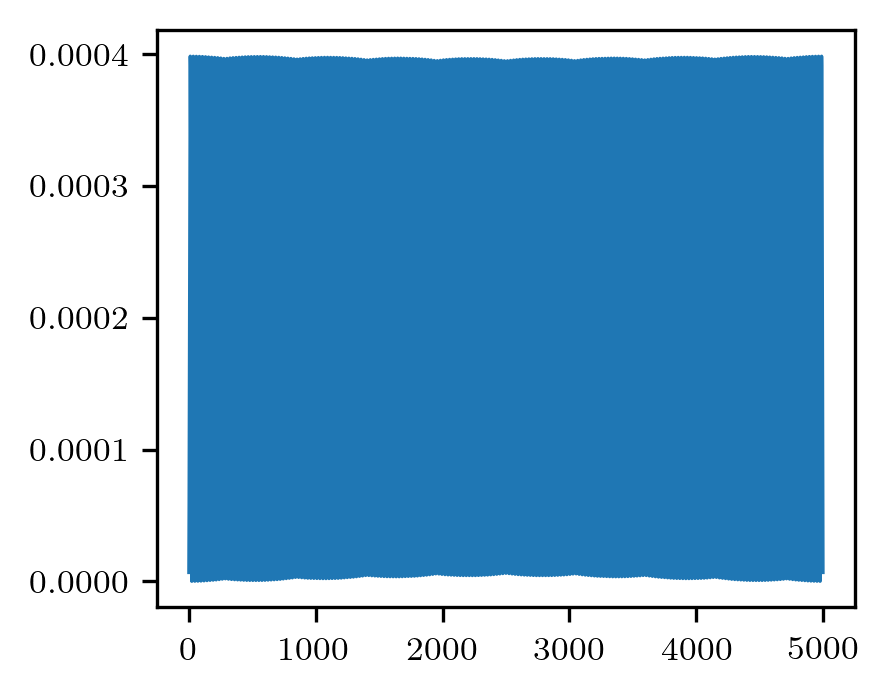

np.float64(1.0000000080226399)

In [50]:
x, y, pd = load_data(f"prob_den.dat")

pd, extent = prep_image_data(x, y, pd)

fig, ax = plt.subplots(figsize=(4.0, 1.5))
mapped = ax.imshow(
    pd, extent=extent, aspect="auto", cmap="Reds", origin="lower", vmin=0
)
fig.colorbar(mapped)

scaling = 5.0
ax.set_box_aspect(scaling * max(y) / max(x))

set_labels(r"$x\ (a)$", r"$y\ (a)$", r"$|\psi|^2$")
save_plot("prob_den.png")
plt.plot(np.sum(pd, axis=0))
# plt.axhline(0.0004, color="black", linestyle="--", linewidth=0.5)
plt.show()

np.sum(pd)

### Band structure 3D

In [ ]:
kx, ky, *energies = load_data("BS.dat")
ukx, uky = np.unique(kx), np.unique(ky)
x, y = np.meshgrid(ukx, uky)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")

for i, e in enumerate(energies):
    ax.plot_surface(x, y, e.reshape(len(ukx), len(uky)).T, alpha=0.5, label=f"{i}")

set_labels(r"$k_x$", r"$k_y$", r"$E$ (meV)")
ax.legend(title="Band index")
save_plot("bands_3d.png")

### Gap closing with changes in mu

In [ ]:
fig, axes = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(5, 5.5))

mu_start, mu_end = -1.0, 1.0

for i, mu in enumerate(np.linspace(mu_start, mu_end, 9)):
    k, *energies = load_data(f"BS{i}.dat")

    for band_idx, E in enumerate(energies):
        axes.flat[i].plot(k, E)

    axes.flat[i].set_title(r"$\mu = " + f"{mu:.2f}"+r"$ meV")

for ax in axes.flat:
    # ax.set_xlim(-1, 1)
    # ax.set_xlim(-0.15, 0.15)

    ax.set_ylim(-2, 2)
    # ax.set_ylim(-4, 0)
    ax.set_xlabel(r"$k_x$ ($1/a$)")
    ax.set_ylabel(r"$E$ (meV)")
    ax.set_box_aspect(1)
    ax.label_outer()
    ax.grid()

save_plot(f"gap_closing.png", dpi=600)

### Chern number vs parameters

In [14]:
def Bz_vs_mu_theo(mu, delta):
    return (
        np.sqrt(mu**2 + delta**2)
        * 0.03674932587122423
        * 0.001
        / (0.5 * 0.5 * (-50))
        / 4.254382e-6
    )


p1, p2, CN = load_data("CN.dat")

Z, e = prep_image_data(p1, p2, CN)

# plt.imshow(Z, extent=e, origin="lower", aspect="auto", cmap="Blues")
plt.imshow(Z, extent=e, origin="lower", aspect="auto", cmap="RdBu")
plt.colorbar()

# mu=p1
# plt.plot(p1, -Bz_vs_mu_theo(p1, 0.2),)
# plt.plot(mu, Bz_vs_mu_theo(mu, 0.2), )

# set_labels(r"$B_x$ (T)", r"$B_y$ (T)")
# save_plot("Bx_By_CN.png");

# set_labels(r"$B_x$ (T)", r"$B_z$ (T)")
# save_plot("Bx_Bz_CN.png")

# set_labels(r"$B_y$ (T)", r"$B_z$ (T)")
# save_plot("By_Bz_CN.png")

# set_labels(r"$B_y$ (T)", r"$B_z$ (T)")
# plt.axhline(Bz_vs_mu_theo(0.0, 0.2), c="k", ls="--", lw=0.5)
# plt.axhline(-Bz_vs_mu_theo(0.0, 0.2), c="k", ls="--", lw=0.5)
# plt.axvline(Bz_vs_mu_theo(0.0, 0.2), c="k", ls="--", lw=0.5)
# plt.axvline(-Bz_vs_mu_theo(0.0, 0.2), c="k", ls="--", lw=0.5)
# save_plot("By_Bz_CN_close.png")

# set_labels(r"$\mu$ (meV)", r"$B_x$ (T)")
# save_plot("mu_Bx_CN.png")

# set_labels(r"$\mu$ (meV)", r"$B_y$ (T)")
# save_plot("mu_By_CN.png")

set_labels(r"$\mu$ (meV)", r"$B_z$ (T)")
save_plot("mu_Bz_CN.png")

### Chern number vs parameters (1D)

In [ ]:
p1, p2, CN = load_data("CN1D.dat")
CN = np.abs(CN)
# CN = np.where(CN > 0.01, CN, 0.0)

Z, e = prep_image_data(p1, p2, CN)

plt.imshow(Z, extent=e, origin="lower", aspect="auto", cmap="Blues", interpolation="None")
plt.colorbar()

# plt.axhline(Bz_vs_mu_theo(0.0, 0.2), c="k", ls="--", lw=0.5)

# set_labels(r"$n$", r"$B_x$ (T)")
# save_plot("n_Bx_CN.png")

# set_labels(r"$n$", r"$B_z$ (T)")
# save_plot("n_Bz_CN.png")

# mu=p1
# plt.plot(p1, -Bz_vs_mu_theo(p1, 0.2),)
# plt.plot(mu, Bz_vs_mu_theo(mu, 0.2), )

# set_labels(r"$B_x$ (T)", r"$B_y$ (T)")
# save_plot("Bx_By_CN.png");

# set_labels(r"$B_x$ (T)", r"$B_z$ (T)")
# save_plot("Bx_Bz_CN.png");

# set_labels(r"$B_y$ (T)", r"$B_z$ (T)")
# save_plot("By_Bz_CN.png")

# set_labels(r"$B_y$ (T)", r"$B_z$ (T)")
# plt.axhline(Bz_vs_mu_theo(0.0, 0.2), c="k", ls="--", lw=0.5)
# plt.axhline(-Bz_vs_mu_theo(0.0, 0.2), c="k", ls="--", lw=0.5)
# plt.axvline(Bz_vs_mu_theo(0.0, 0.2), c="k", ls="--", lw=0.5)
# plt.axvline(-Bz_vs_mu_theo(0.0, 0.2), c="k", ls="--", lw=0.5)
# save_plot("By_Bz_CN_close.png")

set_labels(r"$\mu$ (meV)", r"$B_x$ (T)")
save_plot("mu_Bx_CN.png")

# set_labels(r"$\mu$ (meV)", r"$B_y$ (T)")
# save_plot("mu_By_CN.png")

# set_labels(r"$\mu$ (meV)", r"$B_z$ (T)")
# save_plot("mu_Bz_CN.png")

### Chern number vs single parameter (1D)

In [3]:
p1, CN = load_data("CN1D_single_param.dat")

CN = np.abs(CN)
# CN = np.where(CN > 0.01, CN, 0.0)
plt.plot(p1, CN)
plt.grid(alpha=0.3)

plt.plot(-1.55, 0.5, "ro", markersize=2)

set_labels(r"$\mu$ (meV)", r"$C_{\text{1D}}$")
save_plot("mu_CN1D.png")

### Abelian Berry Curvature

In [ ]:
kx, ky, *BCs = load_data("BC.dat")

n_bands=4
# n_bands=12

fig, axes = plt.subplots(n_bands//4, 4, sharex=True, sharey=True, figsize=(8, 2))

for iBC, BC in enumerate(BCs):
    # BC = symlog10(BC)
    Z, e = prep_image_data(kx, ky, BC)
    cmax = np.abs(BC).max()
    mapped = axes.flat[iBC].imshow(
        Z, extent=e, origin="lower", aspect="equal", cmap="RdBu", vmin=-cmax, vmax=cmax
    )
    axes.flat[iBC].set_xlabel(r"$k_x$")
    axes.flat[iBC].set_ylabel(r"$k_y$")
    axes.flat[iBC].label_outer()
    axes.flat[iBC].set_title(f"Band {iBC}")
    axes.flat[iBC].set_box_aspect(1)
    fig.colorbar(mapped, ax=axes.flat[iBC])
    fig.tight_layout()
    
    # print(f"Band {iBC} sum: {np.sum(BC)}") 

# fig.suptitle(r"Berry Curvature for $\mu = 0.0$ meV")
save_plot(f"BC.png", dpi=300)

BC_sum = np.sum(BCs[:n_bands//2], axis=0)
Z,e = prep_image_data(kx, ky, BC_sum)
plt.imshow(Z, extent=e, origin="lower", aspect="equal", cmap="RdBu")
plt.colorbar()
plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title(r"$\left(\sum \Omega d^2k\right)/\left(2\pi\right)=" + f"{(np.sum(BC_sum)*(np.unique(kx)[1]-kx[0])*(ky[1]-ky[0])/(2*np.pi)):.2f}" + r"$")
save_plot("BC_sum.png")

### Berry Curvature from Wilson Lopp

In [8]:
kx, ky, BC = load_data("BC.dat")

# print(np.sum(BC)/2/ np.pi* (1/300)**2)
cmax = np.abs(BC).max()

Z, e = prep_image_data(kx, ky, BC)
plt.imshow(Z, extent=e, origin="lower", aspect="equal", cmap="RdBu", vmin=-cmax, vmax=cmax)

# Z, e = prep_image_data(kx, ky, np.abs(BC))
# plt.imshow(Z, extent=e, origin="lower", aspect="equal", cmap="Blues")#, vmin=-cmax, vmax=cmax)

plt.colorbar()
set_labels(r"$k_x$", r"$k_y$")
save_plot("BC.png", dpi=300)


### Matrix Berry Curvature Trace

In [ ]:
kx, ky, BC = load_data("BC_trace.dat")

print(np.sum(BC)/2/ np.pi * (1/100)**2)

# BC = symlog10(BC)
Z, e = prep_image_data(kx, ky, BC)
cmax = np.abs(BC).max()
plt.imshow(Z, extent=e, origin="lower", aspect="equal", cmap="RdBu")#, vmin=-cmax, vmax=cmax)
plt.colorbar()
set_labels(r"$k_x$", r"$k_y$")
save_plot("BC_trace.png", dpi=300)

# kx[np.argmax(BC)], ky[np.argmax(BC)], np.max(BC)

FileNotFoundError: build/data/BC_trace.dat not found.

### FS contours

In [ ]:
for i, contour_file in enumerate(glob.glob("build/data/gap_FS*.dat")):
    kx, ky, *_ = np.loadtxt(contour_file, unpack=True)
    plt.plot(kx, ky, label=f"{i}")
    fs = (kx, ky)

plt.xlim(-0.5, 0.5)
plt.ylim(-0.5, 0.5)
plt.gca().set_box_aspect(1)
set_labels(r"$k_x$", r"$k_y$", r"FS")

save_plot("FS.png")

### FS contours and gap along them

In [ ]:
for i, contour_file in enumerate(glob.glob("build/data/gap_FS*.dat")):
    kx, ky, *_ = np.loadtxt(contour_file, unpack=True)
    plt.plot(kx, ky, label=f"{i}")

plt.xlim(-0.5, 0.5)
plt.ylim(-0.5, 0.5)
# plt.xlim(-1.2, 1.2)
# plt.ylim(-1.2, 1.2)
plt.gca().set_box_aspect(1)
set_labels(r"$k_x$", r"$k_y$", r"FS")

save_plot("FS.png")

n_bands = 2

for ib in range(n_bands):
    for i, contour_file in enumerate(glob.glob("build/data/gap_FS*.dat")):
        kx, ky, *gaps = np.loadtxt(contour_file, unpack=True)
        theta = np.arctan2(ky[1:], kx[1:])
        gap = gaps[ib][1:]
        plt.plot(theta, gap, label=f"{i}")

    plt.xlim(-np.pi, np.pi)
    # plt.ylim(0.0, 0.05)
    plt.xticks(
        np.linspace(-np.pi, np.pi, 5),
        [r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"],
    )
    # plt.legend(title="contour idx")
    # plt.yscale("log")
    set_labels(r"$\theta$", r"$\Delta$", r"Gap along FS contours")

    save_plot(f"gap_along_FS_{ib}.png")

# #free up variables
# del  gaps, contour_file, kx, ky, theta, gap

### FS countours colored according to gap - long plotting time


In [ ]:
kx_ky_gap_lst = []
for i, contour_file in enumerate(glob.glob("build/data/gap_FS*.dat")):
    kx, ky, *gaps = np.loadtxt(contour_file, unpack=True)
    kx_ky_gap_lst.append((kx, ky, gaps[0]))

import matplotlib.cm as cm
import matplotlib.colors as mcolors

all_g = np.concatenate([g for _, _, g in kx_ky_gap_lst])
norm = mcolors.Normalize(vmin=all_g.min(), vmax=all_g.max())
cmap = cm.jet  # Colormap

for x, y, z in kx_ky_gap_lst:
    colors = cmap(norm(z))  # Map z-values to colors
    for i in range(len(x) - 1):
        plt.plot(x[i : i + 2], y[i : i + 2], color=colors[i])

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=plt.gca())

set_labels(r"$k_x$", r"$k_y$", r"Gap (meV)")

save_plot("FS_gap_colored.png")

### Abs delta

In [ ]:
kx, ky, *abs_deltas = load_data("abs_delta.dat")

n_bands = 2
rows = n_bands // 2
rows += 0 if rows else 1

fig, axes = plt.subplots(rows, 2, sharex=True, sharey=True, figsize=(4, rows * 2))

for i, (abs_delta, ax) in enumerate(zip(abs_deltas, axes.flat)):
    Z, e = prep_image_data(kx, ky, abs_delta)

    mapped = ax.imshow(
        Z, extent=e, origin="lower", aspect="equal", cmap="jet", 
    )
    
    ax.set_xlabel(r"$k_x$")
    ax.set_ylabel(r"$k_y$")
    ax.set_title(f"Band {i}")
    ax.label_outer()
    ax.set_box_aspect(1)
    fig.colorbar(mapped, ax=ax)
    
    for i, contour_file in enumerate(glob.glob("build/data/gap_FS*.dat")):
        kx_c, ky_c, *_ = np.loadtxt(contour_file, unpack=True)
        ax.plot(kx_c, ky_c, "k-", label=f"{i}")
    
    print(f"Band {i}: min = {np.min(Z)}, max = {np.max(Z)}")
    
fig.suptitle(r"$|\Delta|$ (meV) for $B_z = 0.0$ T")
save_plot("abs_delta.png")

### Abs delta for given k vs B

In [ ]:
B, *abs_deltas = load_data("abs_delta_B.dat")

n_bands = 6
rows = n_bands // 2
rows += 0 if rows else 1

fig, axes = plt.subplots(rows, 2, sharex=True, sharey=True, figsize=(5, rows * 2.5))

for i, (abs_delta, ax) in enumerate(zip(abs_deltas, axes.flat)):
    ax.plot(B, abs_delta)
    
    ax.set_xlabel(r"$B_z$ (T)")
    ax.set_ylabel(r"$|\Delta|$ (meV)")
    ax.set_title(f"Band {i}")
    ax.label_outer()
    ax.set_box_aspect(1)
    ax.grid()
    
fig.suptitle(r"$|\Delta|$ (meV) for $k = (\pi, \pi)$")
save_plot("abs_delta_B.png")

### Delta matrix from unitary transformation

In [ ]:
kx, ky, *abs_deltas = load_data("delta.dat")

n_bands = 2
# n_bands = 6

fig, axes = plt.subplots(n_bands, n_bands*2 , sharex=True, sharey=True, figsize=(n_bands*4, n_bands*2))

for i, ax in enumerate(axes.flat):
    Z, e = prep_image_data(kx, ky, abs_deltas[i])

    idx = i // 2
    
    mapped = ax.imshow(
        Z, extent=e, origin="lower", aspect="equal", cmap="Blues" if i%2 == 0 else "RdBu",
    )
    
    ax.set_xlabel(r"$k_x$")
    ax.set_ylabel(r"$k_y$")
    ax.set_title(r"$\Delta_{" + f"{idx//n_bands}{idx%n_bands}" + r"}$" + f" {'abs' if i%2 == 0 else 'phase'}")
    ax.label_outer()
    ax.set_box_aspect(1)
    fig.colorbar(mapped, ax=ax)
    
    # if i%2 == 0:
    #     print(f"{i=}, min = {np.min(Z)}, max = {np.max(Z)}")

save_plot(f"delta.png", dpi=300)

### Delta matrix from unitary transformation determinant and trace

In [ ]:
kx, ky, *data= load_data("DT.dat")

fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(5, 5))

title = ["Det abs", "Det phase", "Tr abs", "TR phase"] 

for i, ax in enumerate(axes.flat):
    Z, e = prep_image_data(kx, ky, data[i])

    mapped = ax.imshow(
        Z, extent=e, origin="lower", aspect="equal", cmap="Blues" if i%2 == 0 else "RdBu",
    )
    
    ax.set_xlabel(r"$k_x$")
    ax.set_ylabel(r"$k_y$")
    ax.set_title(title[i])
    ax.label_outer()
    ax.set_box_aspect(1)
    fig.colorbar(mapped, ax=ax)
    
    # print(f"{title[i]}: min = {np.min(data[i])}, max = {np.max(data[i])}")
    

save_plot(f"DT.png", dpi=300)

In [ ]:
kz,dre,dim = load_data("delta_test.dat")

fig, axes = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(5, 2.5))

data = [dre, dim]
title = ["Re", "Im"]

for i, ax in enumerate(axes.flat):
    ax.plot(kz, data[i])
    
    ax.set_xlabel(r"$k_z$")
    ax.set_ylabel(r"$\Delta$")
    ax.set_title(title[i])
    ax.label_outer()
    ax.set_box_aspect(1)
    ax.grid()
    
    print(f"{title[i]}: min = {np.min(data[i])}, max = {np.max(data[i])}")
    
save_plot(f"delta_test.png")

### Wilson loop spectrum

In [6]:
k, *evals = load_data("WL.dat")
fig, axes = plt.subplots(1,2, sharex=True, sharey=True, figsize=(5, 2.5))

for i, eval in enumerate(evals[:len(evals)//2]):
    axes.flat[0].scatter(k, eval/np.pi, s=0.5, c="k", edgecolors="none")
    # axes.flat[0].plot(k, eval)
    
for i, eval in enumerate(evals[len(evals)//2:]):
    axes.flat[1].scatter(k, eval/np.pi, s=0.5, c="k", edgecolors="none")
    # axes.flat[1].plot(k, eval)
  
for ax in axes.flat:
    ax.set_ylabel(r"$\theta$ ($\pi$)")
    ax.label_outer()
    ax.set_box_aspect(1)
    ax.grid(alpha=0.5)
    ax.set_ylim(-1, 1)
    
axes.flat[0].set_xlabel(r"$k_x$ (1/$a$)")   
axes.flat[1].set_xlabel(r"$k_y$ (1/$a$)")
    
save_plot(f"WL.png")